<a href="https://colab.research.google.com/github/franciscotovar/wtd/blob/main/Workshop2_HeartRate/Week_6_Motion_to_Meaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



WEARABLE TECH DEVICES
MIET2572

IMPORTANT
Before starting:

Click File → Save a copy in Drive

Work ONLY on your copy

Do NOT edit the original notebook


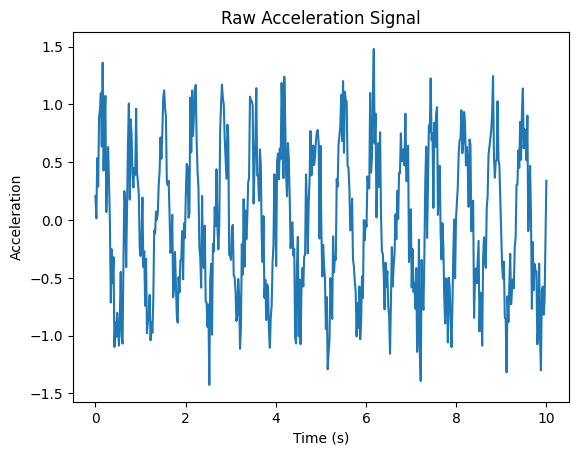

In [ ]:
# =========================
# 📱 WEARABLE DATA STORYTELLING NOTEBOOK
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# -------------------------
# 1. SIMULATED IMU DATA (or replace with your CSV)
# -------------------------

fs = 50  # sampling rate Hz
t = np.linspace(0, 10, fs*10)

# Simulated walking signal
signal = 0.8*np.sin(2*np.pi*1.5*t) + 0.3*np.random.randn(len(t))

plt.figure()
plt.plot(t, signal)
plt.title("Raw Acceleration Signal")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration")
plt.show()

SIMPLE LOW-PASS FILTER

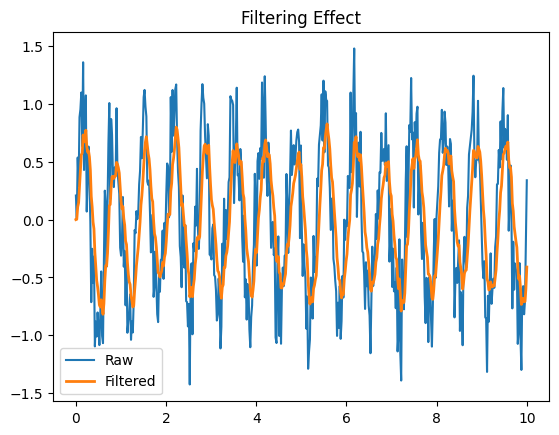

In [ ]:
# -------------------------
# 2. SIMPLE LOW-PASS FILTER
# -------------------------

def low_pass(x, alpha=1):
    y = np.zeros_like(x)
    for i in range(1, len(x)):
        y[i] = alpha*x[i] + (1-alpha)*y[i-1]
    return y

filtered = low_pass(signal, alpha=0.2)

plt.figure()
plt.plot(t, signal, label="Raw")
plt.plot(t, filtered, label="Filtered", linewidth=2)
plt.legend()
plt.title("Filtering Effect")
plt.show()

EVENT Detection

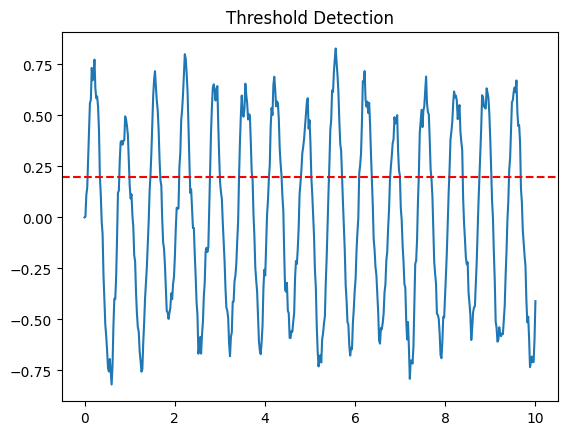

Detected steps: 15


In [ ]:
# -------------------------
# 3. STEP / EVENT DETECTION
# -------------------------

threshold = 0.2

steps = filtered > threshold

plt.figure()
plt.plot(t, filtered)
plt.axhline(threshold, color='r', linestyle='--')
plt.title("Threshold Detection")
plt.show()

num_steps = np.sum((steps[1:] == True) & (steps[:-1] == False))

print("Detected steps:", num_steps)

VISUAL STORYTELLING OUTPUT

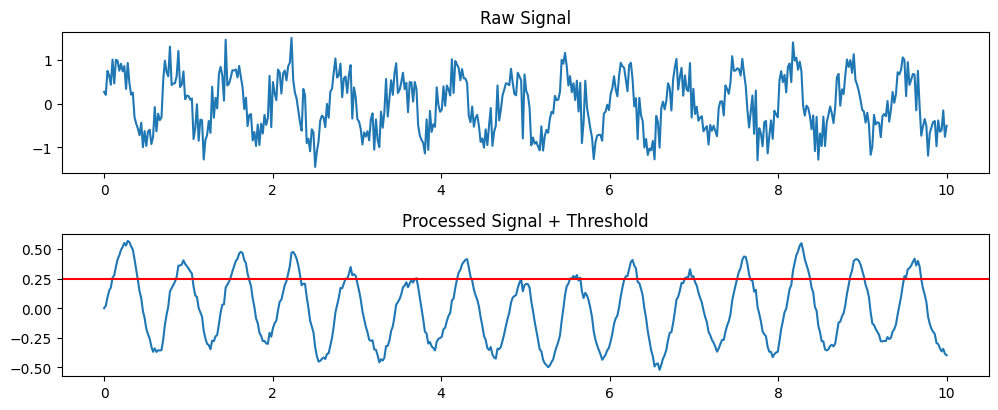

In [ ]:
# -------------------------
# 6. VISUAL STORYTELLING OUTPUT
# -------------------------

plt.figure(figsize=(10,6))

plt.subplot(3,1,1)
plt.plot(t, signal)
plt.title("Raw Signal")

plt.subplot(3,1,2)
plt.plot(t, filtered)
plt.axhline(threshold, color='r')
plt.title("Processed Signal + Threshold")



plt.tight_layout()
plt.show()

Exploring Movement

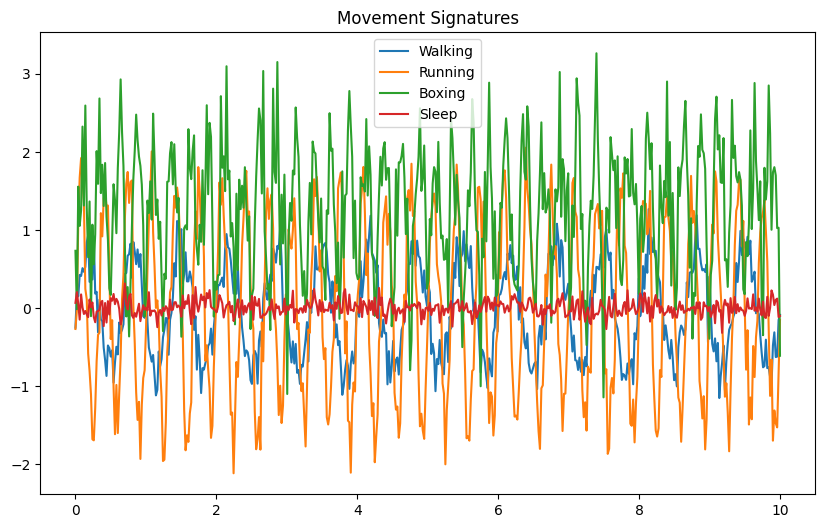

In [ ]:
# Simulated patterns (replace with real data if available)

walk = 0.8*np.sin(2*np.pi*1.5*t) + 0.2*np.random.randn(len(t))
run = 1.5*np.sin(2*np.pi*3*t) + 0.3*np.random.randn(len(t))
box = 2.0*np.abs(np.sin(2*np.pi*2*t)) + 0.5*np.random.randn(len(t))
sleep = 0.1*np.random.randn(len(t))

plt.figure(figsize=(10,6))
plt.plot(t, walk, label='Walking')
plt.plot(t, run, label='Running')
plt.plot(t, box, label='Boxing')
plt.plot(t, sleep, label='Sleep')
plt.legend()
plt.title("Movement Signatures")
plt.show()

FEATURE SPACE

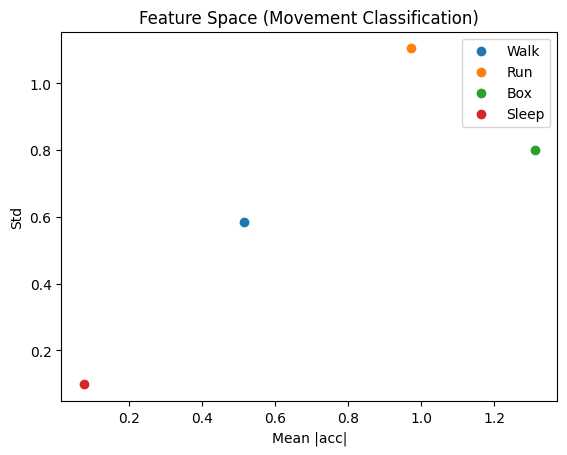

In [ ]:
def features(x):
    return np.mean(np.abs(x)), np.std(x)

fw = features(walk)
fr = features(run)
fb = features(box)
fs = features(sleep)

plt.figure()
plt.scatter(*fw, label='Walk')
plt.scatter(*fr, label='Run')
plt.scatter(*fb, label='Box')
plt.scatter(*fs, label='Sleep')

plt.xlabel("Mean |acc|")
plt.ylabel("Std")
plt.legend()
plt.title("Feature Space (Movement Classification)")
plt.show()



Exploring left/right asymmetry

Detected Steps: 15
Threshold = 0.10 m/s^2
Minimum time between steps = 0.4 s


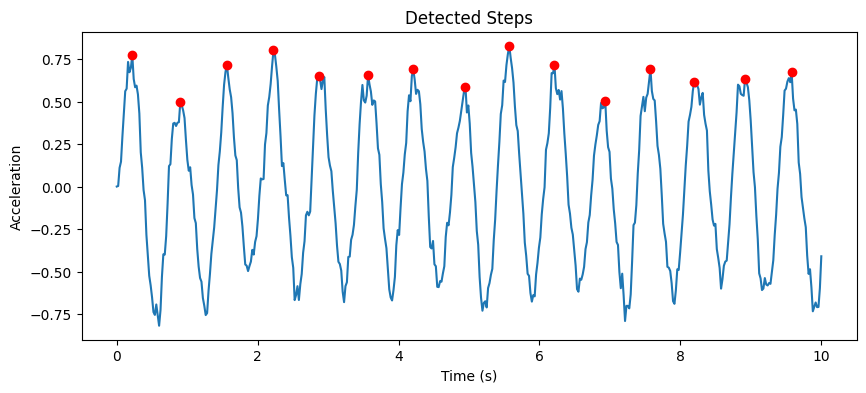

In [ ]:
# ===== MODEL PARAMETERS =====
alpha = 0.1            # amplitude offset above baseline
delta_t_min = 0.4      # minimum time between steps (seconds) # 400 ms physiological constraint
fs = 50


threshold = np.mean(filtered) + alpha
min_distance = int(delta_t_min * fs)


peaks, _ = find_peaks(filtered,
                      height=threshold,
                      distance=min_distance)

step_count = len(peaks)
print("Detected Steps:", step_count)
print(f"Threshold = {threshold:.2f} m/s^2")
print(f"Minimum time between steps = {delta_t_min} s")

plt.figure(figsize=(10,4))
plt.plot(t, filtered)
plt.plot(t[peaks], filtered[peaks], "ro")
plt.title("Detected Steps")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration")
plt.show()

SEPARATE LEFT AND RIGHT

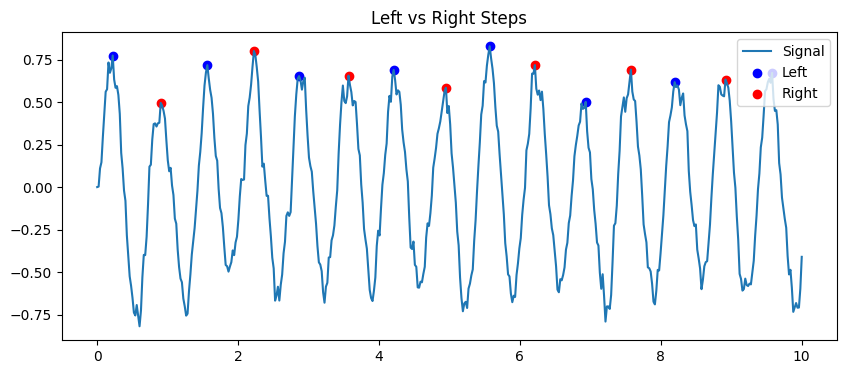

In [ ]:
# Alternating assumption
left_peaks = peaks[::2]
right_peaks = peaks[1::2]

left_times = t[left_peaks]
right_times = t[right_peaks]

plt.figure(figsize=(10,4))

plt.plot(t, filtered, label='Signal')
plt.scatter(t[left_peaks], filtered[left_peaks], color='blue', label='Left')
plt.scatter(t[right_peaks], filtered[right_peaks], color='red', label='Right')

plt.legend()
plt.title("Left vs Right Steps")
plt.show()

We are not measuring left/right directly.
We are assigning left/right based on timing structure. (Inference)

Evaluate assymetry


Detected steps: 15
Asymmetry magnitude: 0.1122373942439244
Symmetry score: 85.97032571950946


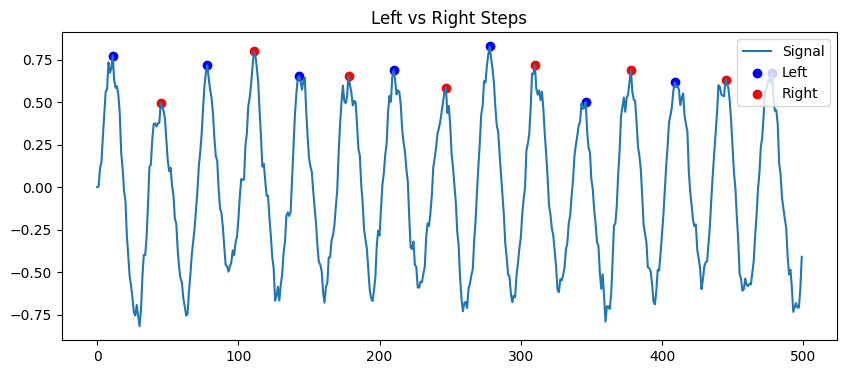

Feedback: Good symmetry


In [ ]:
# =========================
# GAIT ASYMMETRY (SCORE VERSION)
# =========================

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# -------------------------
# 1. PARAMETERS
# -------------------------
alpha = 0.1
delta_t_min = 0.4

threshold = np.mean(filtered) + alpha
min_distance = int(delta_t_min * fs)

# -------------------------
# 2. STEP DETECTION
# -------------------------
peaks, _ = find_peaks(filtered,
                      height=threshold,
                      distance=min_distance)

print("Detected steps:", len(peaks))

# -------------------------
# 3. LEFT / RIGHT SPLIT
# -------------------------
left = filtered[peaks[::2]]
right = filtered[peaks[1::2]]

# -------------------------
# 4. ASYMMETRY FUNCTION (SCORE)
# -------------------------
def compute_symmetry_score(left, right):
    min_len = min(len(left), len(right))

    L = left[:min_len]
    R = right[:min_len]

    # pairwise difference (simple version)
    diff = L - R #diff between steps

    # magnitude of asymmetry
    severity = np.mean(np.abs(diff))  #avg of all abs differences

    # normalized score (0–100). ASSYMETRY INDEX!
    asymmetry_scale = 0.8 # design choice: maximum expected asymmetry:  0 -no assymety means symmetry.
                          # 1 total assymetry, no symmetry
                          # asymmetry_scale defines what we consider "high asymmetry"

    score = 100 * (1 - min(severity / asymmetry_scale, 1))

    return severity, score, L, R

# -------------------------
# 5. COMPUTE
# -------------------------
severity, score, L, R = compute_symmetry_score(left, right)

print("Asymmetry magnitude:", severity)
print("Symmetry score:", score)

# -------------------------
# 6. VISUALIZATION
# -------------------------
plt.figure(figsize=(10,4))

plt.plot(filtered, label='Signal')
plt.scatter(peaks[::2], filtered[peaks[::2]], color='blue', label='Left')
plt.scatter(peaks[1::2], filtered[peaks[1::2]], color='red', label='Right')

plt.legend()
plt.title("Left vs Right Steps")
plt.show()

# -------------------------
# 7. USER FEEDBACK
# -------------------------
if score > 85:
    feedback = "Good symmetry"

elif score > 60:
    feedback = "Moderate symmetry"

else:
    feedback = "Low symmetry"

print("Feedback:", feedback)

EXPLORING OTHER TYPE of FEEDBACK and INDEXs

In [ ]:
def activity_class(mean_val, std_val):
    if std_val < 0.2:
        return "Sleep"
    elif std_val < 0.8:
        return "Walk"
    elif std_val < 1.5:
        return "Run"
    else:
        return "High impact (boxing?)"

print("Detected:", activity_class(*fs))

Detected: Sleep


INDEXs

In [ ]:
# Estimate cadence using peak detection.   #cadence = freq of steps (steps per second)
peak_times = t[peaks]                                     # get its correspondent time example: [0.5 s, 1.1 s, 1.7 s, 2.3 s ...]

if len(peak_times) > 1:
    cadence = 1 / np.mean(np.diff(peak_times))                  # calculate intervals np.diff(peak_times). ex: [0.6, 0.6, 0.6, 0.6]
else:
    cadence = 0

print("Cadence (Hz):", cadence)                        # 1 Hz slow walking.  # 1.5-2Hz walking.  #>3 running

# =========================
# INTERPRETATION
# =========================

if cadence < 0.5:
    state = "Very low movement (rest / no clear steps)"
elif cadence < 1.2:
    state = "Slow walking"
elif cadence < 2.2:
    state = "Walking"
elif cadence < 3.0:
    state = "Fast walking / jogging"
else:
    state = "Running"

print("Detected activity:", state)

Cadence (Hz): 1.4959314775160601
Detected activity: Walking


MOVEMENT INTENSITY

In [ ]:
intensity = np.mean(filtered**2)
norm = np.mean(np.abs(filtered)) + 1e-6

normalized_intensity = intensity / norm
print("Movement intensity:", intensity)         #how strong movement is

if intensity < 0.1:
    state = "Rest"
elif intensity < 0.5:
    state = "Walking"
else:
    state = "High activity"

print("State:", state)

Movement intensity: 0.20144846768525132
State: Walking


REST (sleep) INDEX

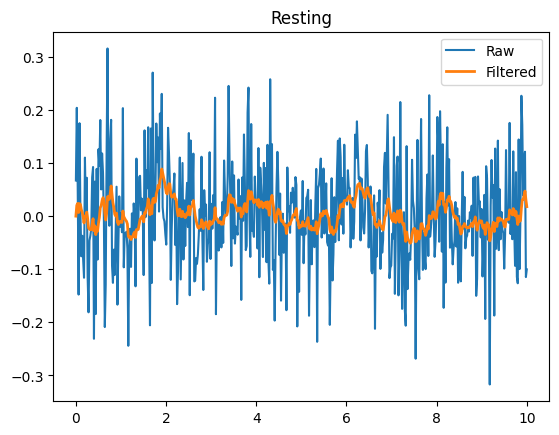

Rest index: 94.95479958483388
State: Resting & Sleeping


In [ ]:
def low_pass(x, alpha=0.2):
    y = np.zeros_like(x)
    for i in range(1, len(x)):
        y[i] = alpha*x[i] + (1-alpha)*y[i-1]
    return y

sleep_filtered = low_pass(sleep, alpha=0.1)

plt.figure()
plt.plot(t, sleep, label="Raw")
plt.plot(t, sleep_filtered, label="Filtered", linewidth=2)
plt.legend()
plt.title("Resting")
plt.show()

movement_variability = np.std(sleep_filtered)         # in resting or sleeping: we expect no change in signal. #standard dev.  How much signal changes?  #more fluctuation -> more movement #less-> no movement

variability_scale = 0.5  # design choice
rest_score = 100 * (1 - min(movement_variability / variability_scale, 1))
print("Rest index:", rest_score)    # degree of stillness

if rest_score > 80:
    state = "Resting & Sleeping"
elif rest_score > 50:
    state = "Light movement"
else:
    state = "Active"

print("State:", state)

FROM THE ACTIVITIES (boxing, Walking, sleeping). Explore assymetry, use an index, or create a new one. Use simulated data (sin function) or real data.

1. Plot your signal
2. Detect something (peaks / variability / amplitude)
3. Define a feature
4. Define an index (formula)
5. Convert it to a score (0–100)
6. Define feedback

Suggested Index:

  •	Walking → symmetry

  •	Boxing → impact
  
  •	Sleep → rest